# Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load Prepared Dataset

In [2]:
data = pd.read_csv(
    "../Data/Processed/solar_prepared.csv"
)

data["time_utc"] = pd.to_datetime(
    data["time_utc"],
    utc=True
)

data["pvgis_time_utc"] = pd.to_datetime(
    data["pvgis_time_utc"],
    utc=True
)

data["time_sl"] = (
    pd.to_datetime(
        data["time_sl"],
        utc=True
    )
    .dt.tz_convert("Asia/Colombo")
)

print("Dataset shape:", data.shape)

Dataset shape: (437975, 26)


Dataset Overview

In [3]:
print("Rows:", len(data))
print("Columns:", len(data.columns))
print("Districts:", data["district"].nunique())

print(
    "Sri Lanka time range:",
    data["time_sl"].min(),
    "to",
    data["time_sl"].max()
)

print("\nColumns:")
print(data.columns.tolist())

Rows: 437975
Columns: 26
Districts: 25
Sri Lanka time range: 2022-01-01 06:30:00+05:30 to 2024-01-01 04:30:00+05:30

Columns:
['time', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation', 'direct_radiation', 'diffuse_radiation', 'direct_normal_irradiance', 'global_tilted_irradiance', 'sunshine_duration', 'is_day', 'district', 'latitude', 'longitude', 'elevation', 'time_utc', 'pvgis_time_utc', 'P', 'pvgis_gi', 'pvgis_h_sun', 'pvgis_t2m', 'pvgis_ws10m', 'pvgis_int', 'time_sl']


In [4]:
data.head()

,time,temperature_2m,relative_humidity_2m,precipitation,cloud_cover,wind_speed_10m,shortwave_radiation,direct_radiation,diffuse_radiation,direct_normal_irradiance,...,elevation,time_utc,pvgis_time_utc,P,pvgis_gi,pvgis_h_sun,pvgis_t2m,pvgis_ws10m,pvgis_int,time_sl
0,2022-01-01T01:00,23.3,94,0.2,100,4.1,1.0,1.0,0.0,0.0,...,37.0,2022-01-01 01:00:00+00:00,2022-01-01 00:30:00+00:00,0.00,0.00,-4.37,23.64,2.21,0.0,2022-01-01 06:30:00+05:30
1,2022-01-01T02:00,23.9,92,0.5,100,3.8,43.0,18.0,25.0,110.8,...,37.0,2022-01-01 02:00:00+00:00,2022-01-01 01:30:00+00:00,29.45,57.05,9.26,23.89,1.66,0.0,2022-01-01 07:30:00+05:30
2,2022-01-01T03:00,25.1,87,0.3,100,4.3,161.0,73.0,88.0,191.0,...,37.0,2022-01-01 03:00:00+00:00,2022-01-01 02:30:00+00:00,138.10,190.06,22.56,24.38,1.24,0.0,2022-01-01 08:30:00+05:30
3,2022-01-01T04:00,26.1,84,0.7,100,7.8,348.0,166.0,182.0,288.8,...,37.0,2022-01-01 04:00:00+00:00,2022-01-01 03:30:00+00:00,284.79,367.82,35.23,25.22,1.52,0.0,2022-01-01 09:30:00+05:30
4,2022-01-01T05:00,27.0,80,1.0,79,10.2,619.0,352.0,267.0,485.6,...,37.0,2022-01-01 05:00:00+00:00,2022-01-01 04:30:00+00:00,487.96,633.72,46.67,26.01,1.66,0.0,2022-01-01 10:30:00+05:30


Check Data Quality

In [5]:
print("Missing values:")
print(
    data.isnull().sum()[
        data.isnull().sum() > 0
    ]
)

print(
    "\nDuplicate district/time:",
    data.duplicated(
        subset=["district", "time_utc"]
    ).sum()
)

Missing values:
precipitation    8625
dtype: int64

Duplicate district/time: 0


Examine PV Output

In [6]:
zero_output = (
    data["P"] == 0
).sum()

positive_output = (
    data["P"] > 0
).sum()

print("Zero output rows:", zero_output)
print("Positive output rows:", positive_output)

print(
    "Zero output percentage:",
    round(
        zero_output / len(data) * 100,
        2
    ),
    "%"
)

Zero output rows: 218685
Positive output rows: 219290
Zero output percentage: 49.93 %


In [13]:
data["P"].describe()

count    437975.000000
mean        162.701131
std         223.419464
min           0.000000
25%           0.000000
50%           0.280000
75%         326.030000
max         819.590000
Name: P, dtype: float64

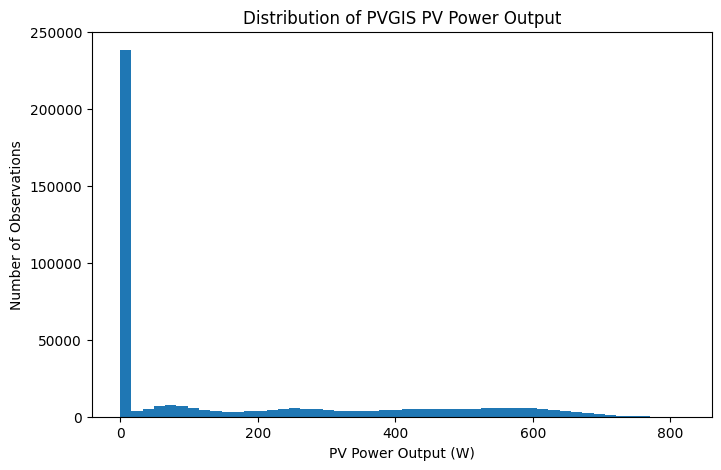

In [7]:
plt.figure(figsize=(8, 5))

plt.hist(
    data["P"],
    bins=50
)

plt.xlabel("PV Power Output (W)")
plt.ylabel("Number of Observations")
plt.title("Distribution of PVGIS PV Power Output")

plt.show()

Compare Day and Night PV Output

In [8]:
day_night_summary = (
    data.groupby("is_day")["P"]
    .agg(
        ["count", "mean", "median", "max"]
    )
)

day_night_summary

,count,mean,median,max
is_day,,,,
0,218441,0.309098,0.00,21.69
1,219534,324.284658,324.95,819.59


In [9]:
pd.crosstab(
    data["is_day"],
    data["P"] == 0,
    rownames=["is_day"],
    colnames=["P equals zero"]
)

P equals zero,False,True
is_day,,
0,12102,206339
1,207188,12346


Examine PV Output by Hour

In [10]:
data["hour"] = data["time_sl"].dt.hour

In [11]:
hourly_output = (
    data.groupby("hour")["P"]
    .mean()
)

hourly_output

hour
0       0.000000
1       0.000000
2       0.000000
3       0.000000
4       0.000000
5       0.000000
6       0.676625
7      67.093729
8     218.611673
9     368.183679
10    479.617021
11    544.569379
12    562.981598
13    533.000835
14    460.743406
15    353.016857
16    222.823272
17     89.116583
18      4.169607
19      0.000000
20      0.000000
21      0.000000
22      0.000000
23      0.000000
Name: P, dtype: float64

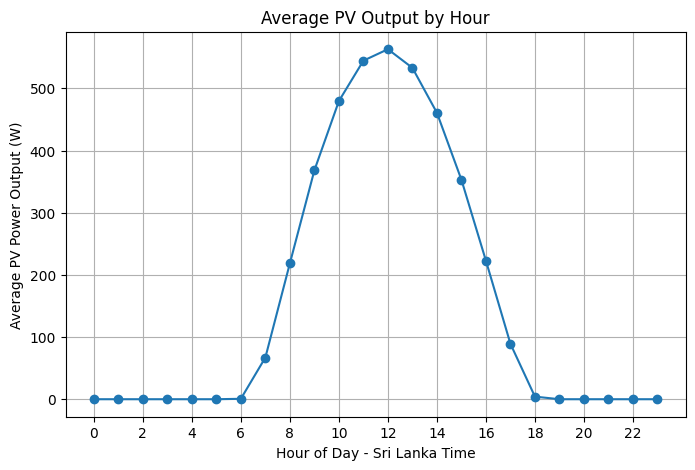

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    hourly_output.index,
    hourly_output.values,
    marker="o"
)

plt.xlabel("Hour of Day - Sri Lanka Time")
plt.ylabel("Average PV Power Output (W)")
plt.title("Average PV Output by Hour")

plt.xticks(range(0, 24, 2))
plt.grid(True)

plt.show()

 Calculate Daily PV Generation

In [26]:
data["date_sl"] = data["time_sl"].dt.date

daily_generation = (
    data.groupby(
        ["district", "date_sl"]
    )["P"]
    .sum()
    .div(1000)
    .reset_index(name="daily_kwh")
)

daily_generation.head()

daily_generation = daily_generation[
    pd.to_datetime(
        daily_generation["date_sl"]
    ).dt.year <= 2023
].copy()

In [27]:
print(
    "Daily records:",
    len(daily_generation)
)

print(
    "First date:",
    daily_generation["date_sl"].min()
)

print(
    "Last date:",
    daily_generation["date_sl"].max()
)

daily_generation["daily_kwh"].describe()

Daily records: 18250
First date: 2022-01-01
Last date: 2023-12-31


count    18250.000000
mean         3.904604
std          0.929478
min          0.194720
25%          3.441108
50%          4.104230
75%          4.543605
max          5.781930
Name: daily_kwh, dtype: float64

Examine Monthly PV Generation

In [16]:
data["month"] = data["time_sl"].dt.month

daily_generation["month"] = pd.to_datetime(
    daily_generation["date_sl"]
).dt.month

In [17]:
monthly_generation = (
    daily_generation.groupby("month")[
        "daily_kwh"
    ]
    .mean()
)

monthly_generation

month
1     4.009257
2     4.303739
3     4.385427
4     4.220530
5     3.847848
6     3.892280
7     3.693649
8     4.213634
9     4.045563
10    3.637260
11    3.330570
12    3.245277
Name: daily_kwh, dtype: float64

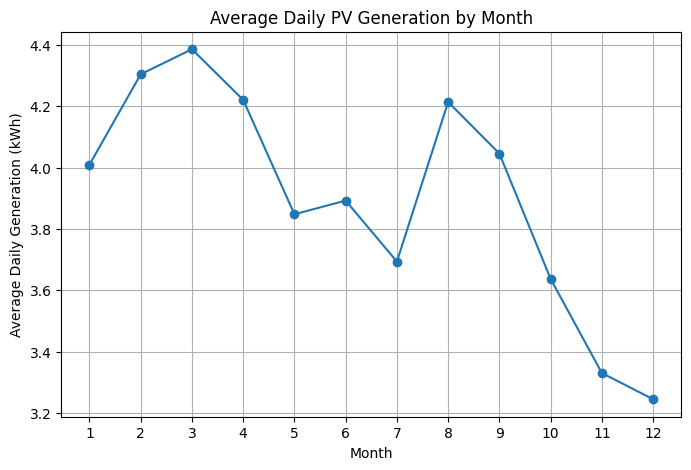

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    monthly_generation.index,
    monthly_generation.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average Daily Generation (kWh)")
plt.title(
    "Average Daily PV Generation by Month"
)

plt.xticks(range(1, 13))
plt.grid(True)

plt.show()

Compare PV Generation by District

In [19]:
district_generation = (
    daily_generation.groupby("district")[
        "daily_kwh"
    ]
    .mean()
    .sort_values(ascending=False)
)

district_generation

district
Mullaitivu      4.195281
Hambantota      4.149127
Matara          4.117757
Trincomalee     4.112689
Galle           4.073132
Jaffna          4.039394
Mannar          4.016706
Kilinochchi     4.013559
Batticaloa      3.966331
Nuwara Eliya    3.948115
Polonnaruwa     3.939693
Badulla         3.903658
Ampara          3.888350
Monaragala      3.870083
Puttalam        3.843323
Kandy           3.840746
Matale          3.836799
Vavuniya        3.795694
Ratnapura       3.734145
Kalutara        3.730954
Anuradhapura    3.729377
Kegalle         3.704420
Kurunegala      3.700932
Colombo         3.666225
Gampaha         3.665081
Name: daily_kwh, dtype: float64

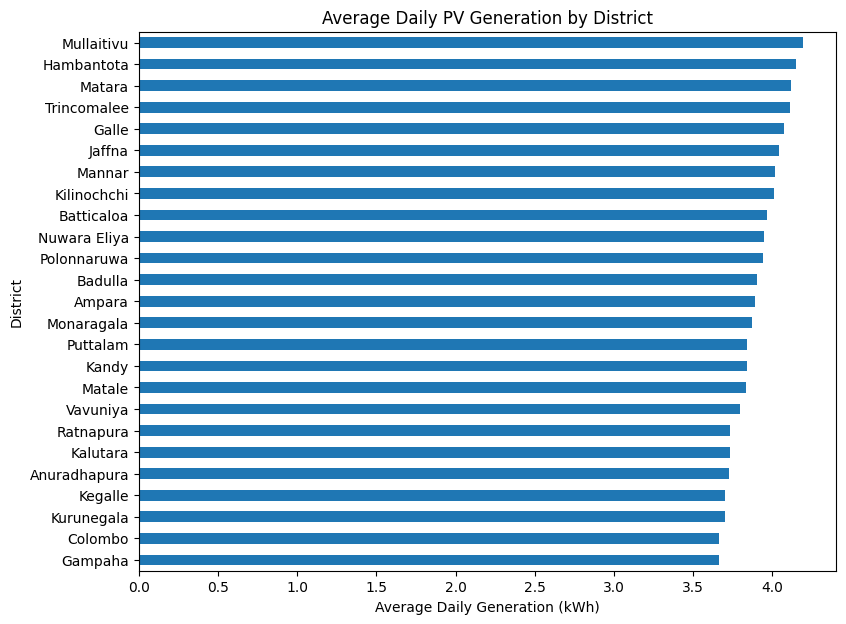

In [20]:
plt.figure(figsize=(9, 7))

district_generation.sort_values().plot(
    kind="barh"
)

plt.xlabel("Average Daily Generation (kWh)")
plt.ylabel("District")
plt.title(
    "Average Daily PV Generation by District"
)

plt.show()

Examine Weather and Radiation Variables

In [21]:
weather_columns = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "cloud_cover",
    "wind_speed_10m",
    "shortwave_radiation",
    "direct_radiation",
    "diffuse_radiation",
    "direct_normal_irradiance",
    "global_tilted_irradiance",
    "sunshine_duration"
]

data[
    weather_columns
].describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_2m,437975.0,25.925336,4.092181,6.3,23.6,25.9,28.4,42.3
relative_humidity_2m,437975.0,78.133939,15.489244,14.0,69.0,82.0,91.0,100.0
precipitation,429350.0,0.251486,0.963222,0.0,0.0,0.0,0.1,86.1
cloud_cover,437975.0,75.773124,35.553232,0.0,51.0,100.0,100.0,100.0
wind_speed_10m,437975.0,10.748927,7.163661,0.0,5.2,8.9,14.8,54.6
shortwave_radiation,437975.0,234.548011,322.923613,0.0,0.0,10.0,459.0,1112.0
direct_radiation,437975.0,161.053432,242.551714,0.0,0.0,4.0,277.0,1015.0
diffuse_radiation,437975.0,73.494578,97.966908,0.0,0.0,6.0,137.0,414.0
direct_normal_irradiance,437975.0,231.537516,296.587933,0.0,0.0,34.2,460.8,1071.1
global_tilted_irradiance,437975.0,235.605186,324.895337,0.0,0.0,9.2,456.4,1149.1


Examine Relationships with PV Output

In [22]:
correlation_columns = (
    weather_columns + ["P"]
)

target_correlations = (
    data[correlation_columns]
    .corr()["P"]
    .drop("P")
    .sort_values(ascending=False)
)

target_correlations

shortwave_radiation         0.943610
global_tilted_irradiance    0.943206
direct_radiation            0.911963
direct_normal_irradiance    0.858439
diffuse_radiation           0.852490
sunshine_duration           0.774601
temperature_2m              0.639565
wind_speed_10m              0.250985
precipitation              -0.028818
cloud_cover                -0.081270
relative_humidity_2m       -0.757181
Name: P, dtype: float64

Compare Daytime Correlations

In [23]:
daytime_data = data[
    data["is_day"] == 1
]

daytime_correlations = (
    daytime_data[correlation_columns]
    .corr()["P"]
    .drop("P")
    .sort_values(ascending=False)
)

daytime_correlations

shortwave_radiation         0.882313
global_tilted_irradiance    0.881608
direct_radiation            0.838161
direct_normal_irradiance    0.691964
diffuse_radiation           0.682580
temperature_2m              0.579812
sunshine_duration           0.474421
wind_speed_10m              0.211536
precipitation              -0.102809
cloud_cover                -0.142406
relative_humidity_2m       -0.685386
Name: P, dtype: float64

Compare Open-Meteo and PVGIS Irradiance

In [25]:
irradiance_comparison = data[
    [
        "global_tilted_irradiance",
        "pvgis_gi"
    ]
].corr()

irradiance_comparison

,global_tilted_irradiance,pvgis_gi
global_tilted_irradiance,1.000000,0.942972
pvgis_gi,0.942972,1.000000


Check Relationships Between Input Variables

In [28]:
candidate_columns = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "cloud_cover",
    "wind_speed_10m",
    "shortwave_radiation",
    "direct_radiation",
    "diffuse_radiation",
    "direct_normal_irradiance",
    "global_tilted_irradiance",
    "sunshine_duration"
]

input_correlations = data[
    candidate_columns
].corr()

input_correlations.round(3)

,temperature_2m,relative_humidity_2m,precipitation,cloud_cover,wind_speed_10m,shortwave_radiation,direct_radiation,diffuse_radiation,direct_normal_irradiance,global_tilted_irradiance,sunshine_duration
temperature_2m,1.000,-0.773,-0.053,-0.067,0.425,0.657,0.638,0.587,0.625,0.648,0.590
relative_humidity_2m,-0.773,1.000,0.155,0.120,-0.362,-0.757,-0.745,-0.649,-0.739,-0.752,-0.674
precipitation,-0.053,0.155,1.000,0.108,-0.037,-0.031,-0.043,0.006,-0.054,-0.030,-0.033
cloud_cover,-0.067,0.120,0.108,1.000,0.013,-0.128,-0.204,0.083,-0.241,-0.131,-0.090
wind_speed_10m,0.425,-0.362,-0.037,0.013,1.000,0.268,0.249,0.266,0.241,0.259,0.247
shortwave_radiation,0.657,-0.757,-0.031,-0.128,0.268,1.000,0.980,0.870,0.934,0.998,0.824
direct_radiation,0.638,-0.745,-0.043,-0.204,0.249,0.980,1.000,0.754,0.947,0.980,0.764
diffuse_radiation,0.587,-0.649,0.006,0.083,0.266,0.870,0.754,1.000,0.734,0.864,0.823
direct_normal_irradiance,0.625,-0.739,-0.054,-0.241,0.241,0.934,0.947,0.734,1.000,0.938,0.877
global_tilted_irradiance,0.648,-0.752,-0.030,-0.131,0.259,0.998,0.980,0.864,0.938,1.000,0.823


 Plot Correlation with PV Output

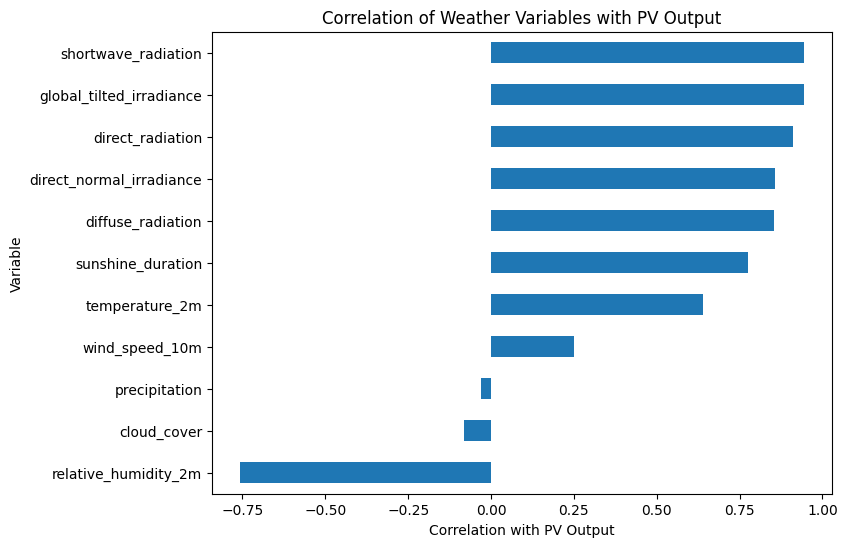

In [29]:
target_correlations.sort_values().plot(
    kind="barh",
    figsize=(8, 6)
)

plt.xlabel("Correlation with PV Output")
plt.ylabel("Variable")
plt.title("Correlation of Weather Variables with PV Output")

plt.show()

Examine Cloud Cover and PV Output

In [30]:
cloud_summary = (
    daytime_data
    .assign(
        cloud_group=pd.cut(
            daytime_data["cloud_cover"],
            bins=[0, 20, 40, 60, 80, 100],
            include_lowest=True
        )
    )
    .groupby(
        "cloud_group",
        observed=True
    )["P"]
    .agg(["count", "mean", "median"])
)

cloud_summary

,count,mean,median
cloud_group,,,
"(-0.001, 20.0]",33645,369.075610,402.06
"(20.0, 40.0]",15179,365.394602,404.56
"(40.0, 60.0]",14135,377.681643,419.69
"(60.0, 80.0]",15092,356.136547,387.03
"(80.0, 100.0]",141483,300.490461,287.81


Examine Rainfall and PV Output

In [31]:
rain_summary = (
    daytime_data
    .dropna(subset=["precipitation"])
    .assign(
        raining=lambda x: x["precipitation"] > 0
    )
    .groupby("raining")["P"]
    .agg(["count", "mean", "median"])
)

rain_summary

,count,mean,median
raining,,,
False,149548,338.653628,352.050
True,65686,294.975979,284.425


In [32]:
print(
    "Daytime precipitation correlation:",
    daytime_data[
        ["precipitation", "P"]
    ]
    .corr()
    .loc["precipitation", "P"]
)

Daytime precipitation correlation: -0.10280905667110041


Examine Sunshine Duration and PV Output

In [33]:
sunshine_summary = (
    daytime_data[
        ["sunshine_duration", "P"]
    ]
    .corr()
)

sunshine_summary

,sunshine_duration,P
sunshine_duration,1.000000,0.474421
P,0.474421,1.000000


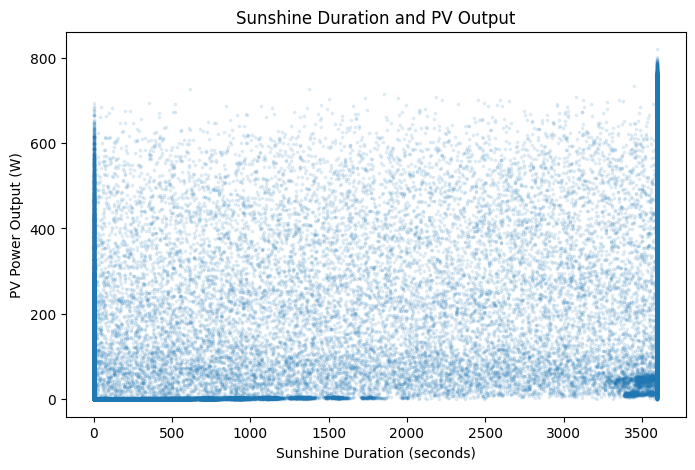

In [34]:
plt.figure(figsize=(8, 5))

plt.scatter(
    daytime_data["sunshine_duration"],
    daytime_data["P"],
    s=3,
    alpha=0.1
)

plt.xlabel("Sunshine Duration (seconds)")
plt.ylabel("PV Power Output (W)")
plt.title("Sunshine Duration and PV Output")

plt.show()

Compare Generation Between Years

In [35]:
daily_generation["year"] = pd.to_datetime(
    daily_generation["date_sl"]
).dt.year

year_summary = (
    daily_generation
    .groupby("year")["daily_kwh"]
    .agg(["count", "mean", "median", "std"])
)

year_summary

,count,mean,median,std
year,,,,
2022,9125,3.946852,4.13507,0.927099
2023,9125,3.862356,4.07177,0.929984
